##### 常數

In [1]:
NAME = "pose1"

VIDEO = f"../../../../resources/video/20240705/2/{NAME}.mp4"  # 影片路徑
MODEL = "./models/BlazePose/pose_landmarker_full.task"  # 模型路徑

#### 套件

In [2]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg
import mediapipe as mp
import cv2

from mediapipe.tasks.python.core.base_options import BaseOptions
from mediapipe.tasks.python.vision.core.vision_task_running_mode import (
    VisionTaskRunningMode,
)
from mediapipe.tasks.python.vision.pose_landmarker import (
    PoseLandmarker,
    PoseLandmarkerOptions,
)

In [3]:
from mpl_toolkits.mplot3d.axes3d import Axes, Axes3D
from mediapipe.tasks.python.vision.pose_landmarker import PoseLandmarkerResult

In [4]:
from src.mediapipe_lib.base import LhcPoseListAnalyzer
from src.draw_template import get_bones_plot_axes
from src.utils.plot_painter import (
    set_data_range,
    set_plot_labels,
    draw_bool_list_line_chart,
    draw_pose_result_line_chart,
    plot_to_opencv_img,
)
from src.server_api import get_video_json_result

#### 忽略警告

In [5]:
import warnings


warnings.filterwarnings("ignore")

#### 函式

##### 設定圖表座標資訊

In [6]:
def set_axes_info(is_3d: bool, ax: Axes | Axes3D) -> Axes | Axes3D:
    """設定圖表座標資訊
    Args:
        is_3d (bool): 是否為 3D 姿勢
        ax (Axes | Axes3D): 圖表座標
    Returns:
        Axes | Axes3D: 圖表座標
    """
    # 設定圖表座標資訊
    if not is_3d:
        set_plot_labels("x", "y", ax=ax)  # 設定標籤
        set_data_range([0, 1], [1, 0], ax=ax)  # 設定資料範圍
    else:
        set_plot_labels("x", "z", "y", ax)  # 設定標籤
        set_data_range([-1, 1], [-1, 1], [0, 2], ax)  # 設定資料範圍
    return ax

##### 繪製分析結果圖表

In [7]:
def save_result_plot(
    result: PoseLandmarkerResult,
    saved_path: str = "result_plot.png",
    figsize: tuple[float, float] = (6.4, 4.8),
    is_3d: bool = False,
) -> cv2.typing.MatLike:
    """儲存分析結果圖表

    Args:
        result (PoseLandmarkerResult): 姿勢結果
        saved_path (str, optional): 儲存路徑. Defaults to "result_plot.png".
        figsize (tuple[float, float], optional): 圖表大小. Defaults to (6.4, 4.8).
        is_3d (bool, optional): 是否為 3D 姿勢. Defaults to False.

    Returns:
        cv2.typing.MatLike: 圖表圖片
    """

    # 建立圖表
    fig = plt.figure(figsize=figsize)
    ax: Axes3D = fig.add_subplot(projection="3d")
    ax.view_init(0, 270, 0)
    set_axes_info(is_3d, ax)  # 設定圖表座標資訊

    # 繪製表格
    if len(result.pose_world_landmarks) > 0:
        get_bones_plot_axes(result, is_3d=is_3d, ax=ax)
        ax.legend()
    else:
        ax.set_title("NO DATA")

    fig.savefig(saved_path)
    img = plot_to_opencv_img(fig)

    plt.close(fig)  # 關閉圖表

    return img

#### 開始測試

In [8]:
# 模型設定
options = PoseLandmarkerOptions(
    base_options=BaseOptions(MODEL), running_mode=VisionTaskRunningMode.VIDEO
)

# 使用 3D 模型
is_3d = True

# 影片輸出
zoom_ratio = 0.5  # 影片縮放倍率
fourcc = cv2.VideoWriter.fourcc(*"mp4v")  # fourcc 碼
fps = 30  # 幀率

In [14]:
cap = cv2.VideoCapture(VIDEO)  # 取得串流資訊
lhc_analyzer = LhcPoseListAnalyzer()  # LHC 姿勢分析物件
landmarker = PoseLandmarker.create_from_options(options)  # 建立模型物件

# 進行串流
idx = 0
while cap.isOpened():
    # 抓取影像
    ret, frame = cap.read()
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    # 取得並儲存影像分析結果
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
    result = landmarker.detect_for_video(mp_img, int(cap.get(cv2.CAP_PROP_POS_MSEC)))

    # 如果成功在圖片中取得人體姿勢，則加入結果到 lhc_analyzer 中
    if len(result.pose_landmarks) > 0:
        lhc_analyzer += [result]
        if idx % 23 == 0:
            # 儲存分析結果
            cv2.imwrite(f"./output_plot/origin/origin-{NAME}_{idx}.png", frame)  # 原始圖片
            # 分析圖表
            save_result_plot(
                result, f"./output_plot/plot/plot-{NAME}_{idx}.png", (5, 5), is_3d
            )
        idx += 1

cap.release()
landmarker.close()
print("finish")

Can't receive frame (stream end?). Exiting ...
94
finish


In [10]:
if True:
    results = get_video_json_result(VIDEO)
    for key, val in results.items():
        print(key, val, sep='  \t')

Can't receive frame (stream end?). Exiting ...
extra scores: [3. 3. 0. 0.]
sum of extra scores: 6.0
extra scores: [3. 3. 0. 0.]
sum of extra scores: 6.0
start  	A4
end  	A3
extra 1  	FREQUENTLY_OR_CONSTANTLY
extra 2  	FREQUENTLY_OR_CONSTANTLY
extra 3  	RARELY
extra 4  	RARELY
pose score  	10
extra score  	6.0
total score  	16.0


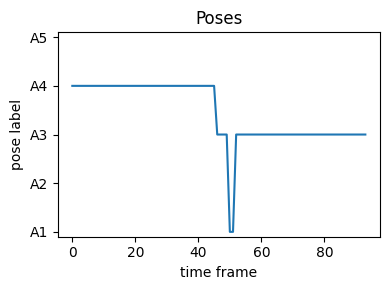

In [11]:
if True:
    fig = plt.figure(figsize=(4, 3))
    ax = fig.add_subplot()
    ax.set_title("Poses")
    draw_pose_result_line_chart(lhc_analyzer.get_lhc_label_list(is_3d), "pose label", ax)
    fig.tight_layout()
    fig.savefig('./output_plot/身體姿勢變化.png')

In [12]:
if True:
    # 軀幹扭轉/側傾
    fig = plt.figure(figsize=(4, 3))
    ax = fig.add_subplot()
    ax.set_title(
        f"trunk is twisted, {lhc_analyzer.get_frequency_of_trunk_is_twisted(is_3d).name}"
    )
    draw_bool_list_line_chart(
        lhc_analyzer.get_trunk_is_twisted_list(is_3d), "result", ax=ax
    )
    ax.legend()
    fig.tight_layout()
    fig.savefig("./output_plot/額外加分_1 - 軀幹扭轉側傾.png")
    plt.close()

if True:
    # 手或重心遠離身體
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot()
    ax.set_title(
        f"hands at a distance, {lhc_analyzer.get_frequency_of_hands_at_a_distance(is_3d).name}"
    )
    draw_bool_list_line_chart(
        lhc_analyzer.get_hands_at_a_distance_list(is_3d), "result", ax=ax
    )
    ax.legend()
    fig.savefig("./output_plot/額外加分_2 - 手或重心遠離身體.png")
    plt.close()

if True:
    # 手臂抬舉，手的水平位於手肘與肩膀之間
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot()
    ax.set_title(
        f"arms raised, {lhc_analyzer.get_frequency_of_arms_raised(is_3d).name}"
    )
    draw_bool_list_line_chart(lhc_analyzer.get_arms_raised_list(is_3d), "result", ax=ax)
    ax.legend()
    fig.savefig("./output_plot/額外加分_3 - 手臂抬舉，手的水平位於手肘與肩膀之間.png")
    plt.close()

if True:
    # 手高過肩膀
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot()
    ax.set_title(
        f"hands above shoulder, {lhc_analyzer.get_frequency_of_hands_above_shoulder(is_3d).name}"
    )
    draw_bool_list_line_chart(
        lhc_analyzer.get_hands_above_shoulder_list(is_3d), "result", ax=ax
    )
    ax.legend()
    fig.savefig("./output_plot/額外加分_4 - 手高過肩膀.png")
    plt.close()

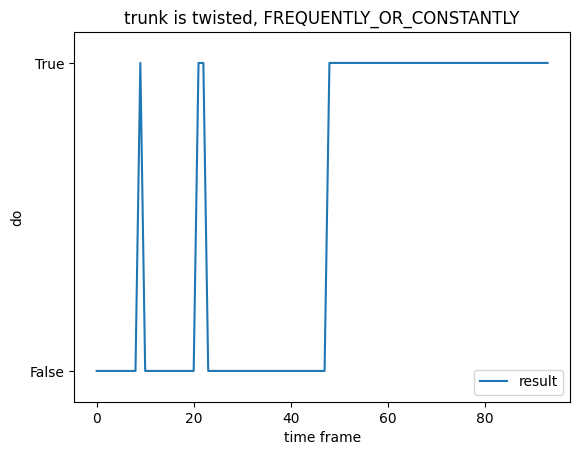

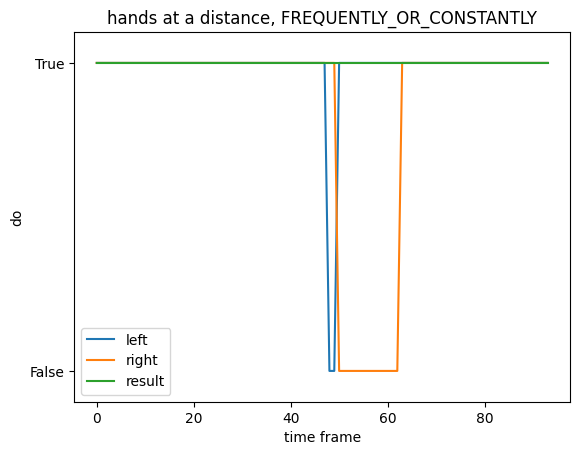

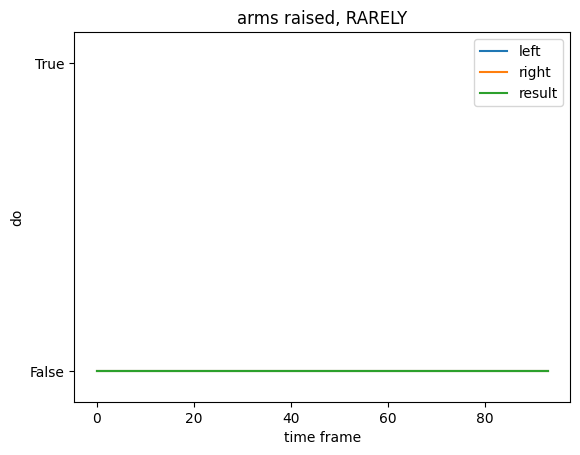

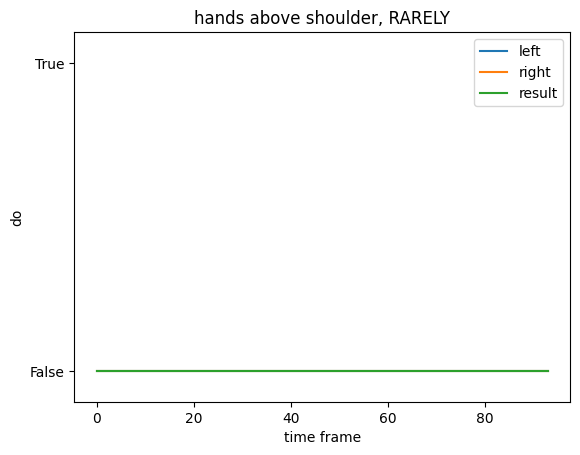

In [13]:
if True:
    # 軀幹扭轉/側傾
    plt.title(
        f"trunk is twisted, {lhc_analyzer.get_frequency_of_trunk_is_twisted(is_3d).name}"
    )
    draw_bool_list_line_chart(lhc_analyzer.get_trunk_is_twisted_list(is_3d), "result")
    plt.legend()
    plt.show()


if True:
    # 手或重心遠離身體
    plt.title(
        f"hands at a distance, {lhc_analyzer.get_frequency_of_hands_at_a_distance(is_3d).name}"
    )
    draw_bool_list_line_chart(
        lhc_analyzer.get_hands_at_a_distance_list_by_one_side(True, is_3d), "left"
    )
    draw_bool_list_line_chart(
        lhc_analyzer.get_hands_at_a_distance_list_by_one_side(False, is_3d), "right"
    )
    draw_bool_list_line_chart(
        lhc_analyzer.get_hands_at_a_distance_list(is_3d), "result"
    )
    plt.legend()
    plt.show()

if True:
    # 手臂抬舉，手的水平位於手肘與肩膀之間
    plt.title(f"arms raised, {lhc_analyzer.get_frequency_of_arms_raised(is_3d).name}")
    draw_bool_list_line_chart(
        lhc_analyzer.get_arms_raised_list_by_one_side(True, is_3d), "left"
    )
    draw_bool_list_line_chart(
        lhc_analyzer.get_arms_raised_list_by_one_side(False, is_3d), "right"
    )
    draw_bool_list_line_chart(lhc_analyzer.get_arms_raised_list(is_3d), "result")
    plt.legend()
    plt.show()

if True:
    # 手高過肩膀
    plt.title(
        f"hands above shoulder, {lhc_analyzer.get_frequency_of_hands_above_shoulder(is_3d).name}"
    )
    draw_bool_list_line_chart(
        lhc_analyzer.get_hands_above_shoulder_list_by_one_side(True, is_3d), "left"
    )
    draw_bool_list_line_chart(
        lhc_analyzer.get_hands_above_shoulder_list_by_one_side(False, is_3d), "right"
    )
    draw_bool_list_line_chart(
        lhc_analyzer.get_hands_above_shoulder_list(is_3d), "result"
    )
    plt.legend()
    plt.show()